In [1]:
import pandas as pd
import numpy as np
import category_encoders as ce
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt

seed = 42

## Obtener los datos del "Seeds Dataset (UCI Machine Learning Repository)"

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00236/seeds_dataset.txt"

cols = ["Area", "Perimeter", "Compactness", "Length_kernel", "Width_kernel",
        "Asymmetry_coeff", "Length_groove", "Class"]
df = pd.read_csv(url, sep="\s+", names=cols)

print(df['Class'].unique())

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
C:\Users\guzco\AppData\Local\Temp\ipykernel_23424\2585643856.py:5: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(url, sep="\s+", names=cols)


[1 2 3]


In [3]:
df.head()

,Area,Perimeter,Compactness,Length_kernel,Width_kernel,Asymmetry_coeff,Length_groove,Class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1


In [4]:
df.shape

(210, 8)

In [6]:
# Calcular el IR
counts = df['Class'].value_counts()
IR = counts.max() / counts.min()
print(f"Imbalance Ratio (IR): {IR:.2f}")

Imbalance Ratio (IR): 1.00


## Ubicar valores nulos, repetidos e indiscernibles

In [7]:
# Sin valores nulos
df.isnull().sum()

Area               0
Perimeter          0
Compactness        0
Length_kernel      0
Width_kernel       0
Asymmetry_coeff    0
Length_groove      0
Class              0
dtype: int64

In [8]:
# Valores repetidos
df.duplicated().sum()

np.int64(0)

In [12]:
# Valores indiscernibles
X = df.drop('Class', axis = 1)
Y = df['Class']

df_copia = df.copy()

indiscernibles = df_copia.groupby(list(X.columns))['Class'].nunique()
indiscernibles = indiscernibles[indiscernibles > 1]
len(indiscernibles)

df.shape

(210, 8)

## Revolver datos porque vienen ordenados y me van a sesgar el modelo

In [14]:
df = df.sample(frac = 1)
df['Class'].value_counts()

Class
1    70
2    70
3    70
Name: count, dtype: int64

In [15]:
df.head()

,Area,Perimeter,Compactness,Length_kernel,Width_kernel,Asymmetry_coeff,Length_groove,Class
30,13.16,13.82,0.8662,5.454,2.975,0.8551,5.056,1
139,16.23,15.18,0.8850,5.872,3.472,3.7690,5.922,2
24,15.01,14.76,0.8657,5.789,3.245,1.7910,5.001,1
18,14.70,14.21,0.9153,5.205,3.466,1.7670,4.649,1
149,10.79,12.93,0.8107,5.317,2.648,5.4620,5.194,3


## Reetiquetar las clases

In [17]:
# Etiqueta de clase numérica con un diccionario
# 0 --> clase negativa
# 1 --> clase positiva
df['Class'] = df['Class']-1
df.head()

,Area,Perimeter,Compactness,Length_kernel,Width_kernel,Asymmetry_coeff,Length_groove,Class
30,13.16,13.82,0.8662,5.454,2.975,0.8551,5.056,0
139,16.23,15.18,0.8850,5.872,3.472,3.7690,5.922,1
24,15.01,14.76,0.8657,5.789,3.245,1.7910,5.001,0
18,14.70,14.21,0.9153,5.205,3.466,1.7670,4.649,0
149,10.79,12.93,0.8107,5.317,2.648,5.4620,5.194,2


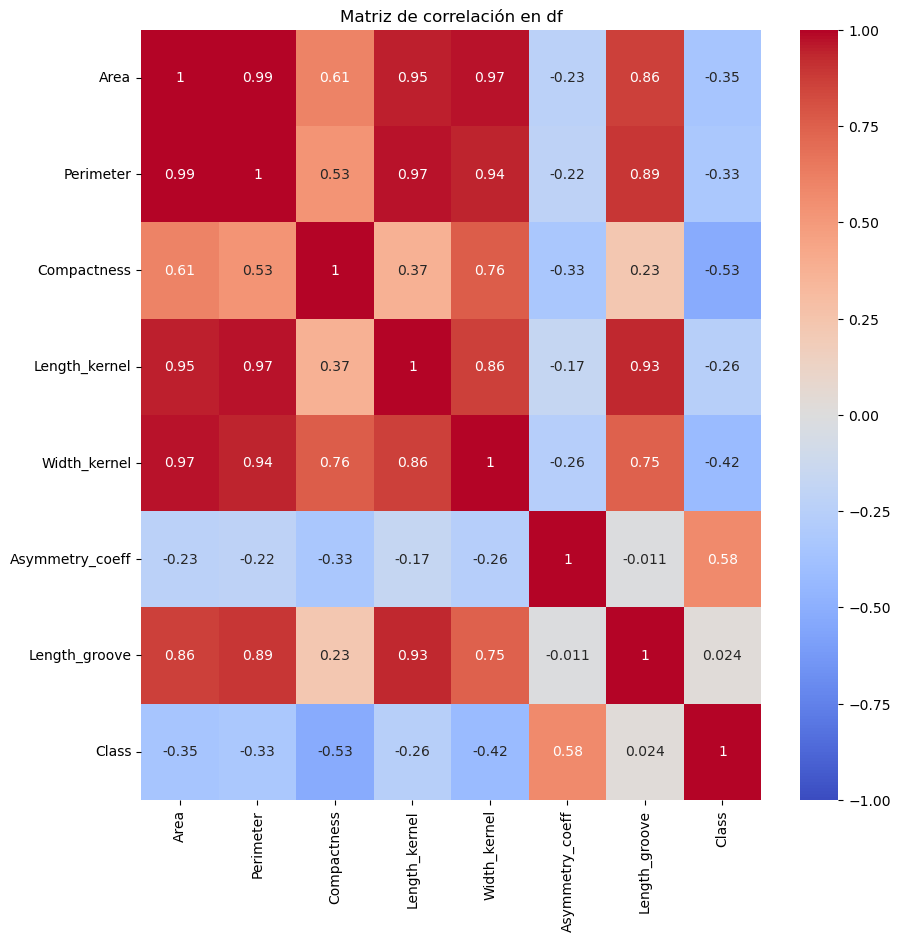

In [18]:
corr_matrix = df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm',
            vmin=-1,
            vmax=1)
plt.title("Matriz de correlación en df")
plt.show()
# Hay que quitarle las características 6, 7 y 8 porque son constantes.

## Normalización de las características numericas


In [19]:
# Estandarizar para que no afecte a los algoritmos basados en distancias como el SVM o los KNN
scaler = MinMaxScaler()

numericos = [col for col in df.columns if col != 'Class']

df_numericos_scaled = scaler.fit_transform(df[numericos])
df_numericos_scaled = pd.DataFrame(df_numericos_scaled, columns = numericos)
df_numericos_scaled.head()

,Area,Perimeter,Compactness,Length_kernel,Width_kernel,Asymmetry_coeff,Length_groove
0,0.242682,0.291322,0.527223,0.312500,0.245902,0.011702,0.264402
1,0.532578,0.572314,0.697822,0.547860,0.600143,0.390578,0.690793
2,0.417375,0.485537,0.522686,0.501126,0.438346,0.133391,0.237322
3,0.388102,0.371901,0.972777,0.172297,0.595866,0.130271,0.064008
4,0.018886,0.107438,0.023593,0.235360,0.012830,0.610709,0.332349


## Unir los numericos normalizados con la clase en un df final

In [21]:
df_final = pd.concat([df_numericos_scaled.reset_index(drop = True), 
                      df['Class'].reset_index(drop = True)], axis = 1)
df_final.head()

,Area,Perimeter,Compactness,Length_kernel,Width_kernel,Asymmetry_coeff,Length_groove,Class
0,0.242682,0.291322,0.527223,0.312500,0.245902,0.011702,0.264402,0
1,0.532578,0.572314,0.697822,0.547860,0.600143,0.390578,0.690793,1
2,0.417375,0.485537,0.522686,0.501126,0.438346,0.133391,0.237322,0
3,0.388102,0.371901,0.972777,0.172297,0.595866,0.130271,0.064008,0
4,0.018886,0.107438,0.023593,0.235360,0.012830,0.610709,0.332349,2


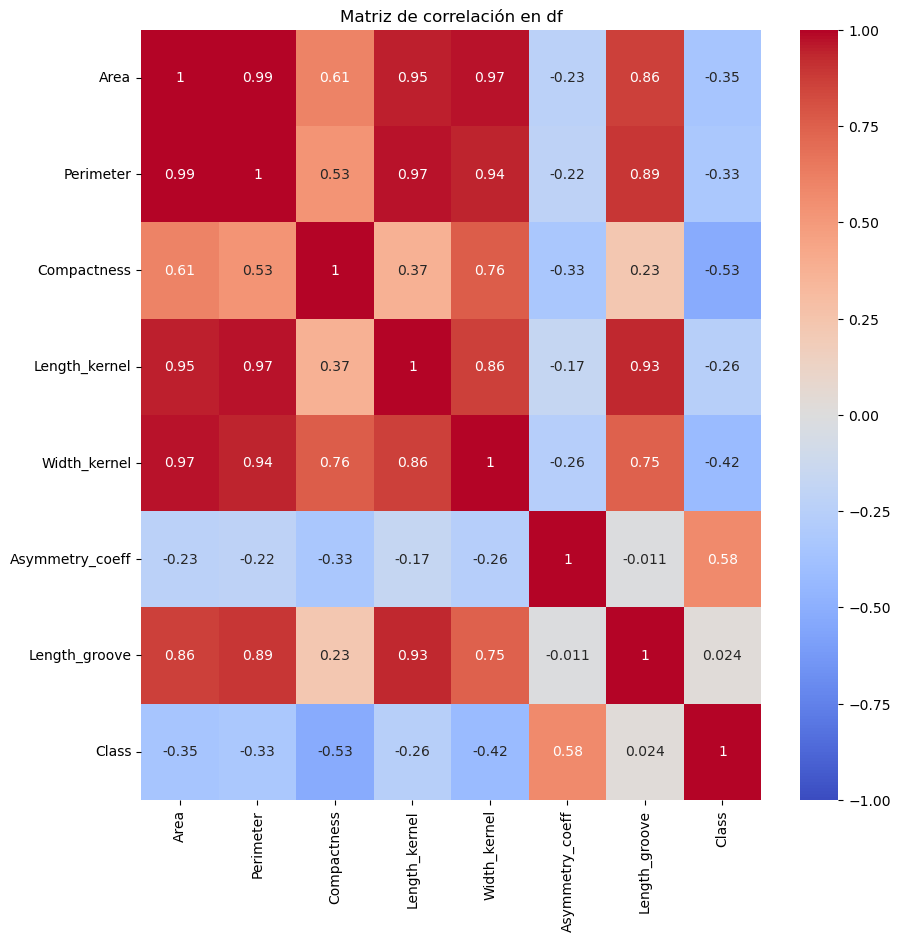

In [22]:
corr_matrix = df_final.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm',
            vmin=-1,
            vmax=1)
plt.title("Matriz de correlación en df")
plt.show()

## Eliminacion de variables con mas de .9 de correlación 

In [33]:
# Definir umbral de correlación
threshold = 0.9  

# Crear una máscara booleana para la matriz superior
corr_matrix_upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Seleccionar columnas que tienen correlación mayor al umbral
cols_to_drop = [column for column in corr_matrix_upper.columns if any(corr_matrix_upper[column].abs() > threshold)]

# Mostrar columnas que se eliminarán
print("Columnas con alta correlación (> 0.9):", cols_to_drop)

Columnas con alta correlación (> 0.9): ['Perimeter', 'Length_kernel', 'Width_kernel', 'Length_groove']


In [34]:
df_reduced = df_final.drop(columns=cols_to_drop)

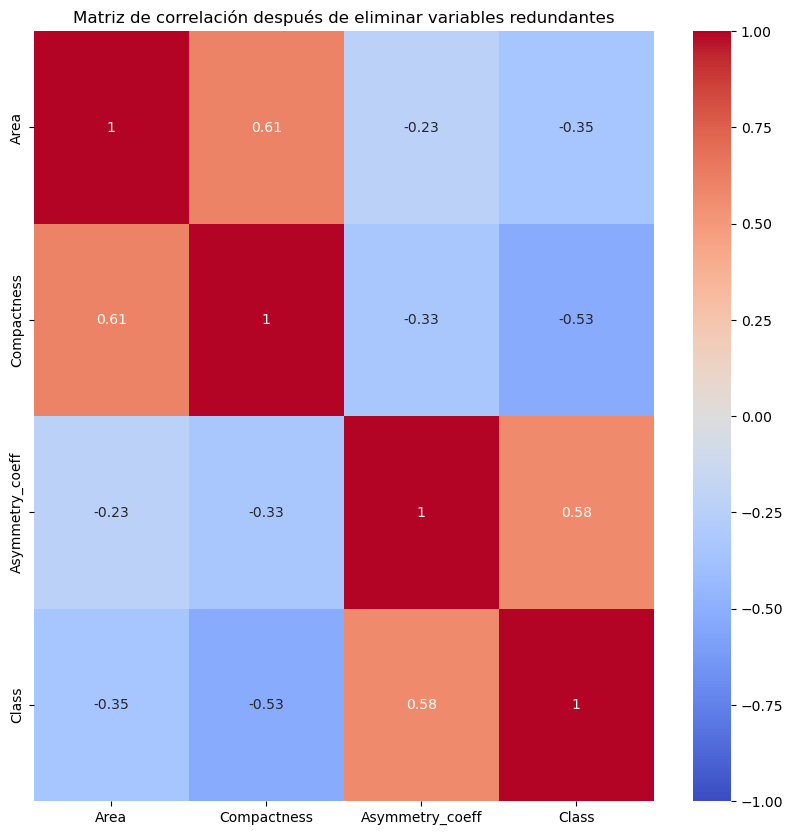

In [35]:
plt.figure(figsize=(10,10))
sns.heatmap(df_reduced.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Matriz de correlación después de eliminar variables redundantes")
plt.show()

In [36]:
df_reduced.head()

,Area,Compactness,Asymmetry_coeff,Class
0,0.242682,0.527223,0.011702,0
1,0.532578,0.697822,0.390578,1
2,0.417375,0.522686,0.133391,0
3,0.388102,0.972777,0.130271,0
4,0.018886,0.023593,0.610709,2


## Guardar Dataset FInal

In [26]:
df_final.to_csv('Seed_limpio.csv', index = False)

In [38]:
df_final.to_csv('Seed_limpio_eliminacion_correlacio.csv', index = False)